<a href="https://colab.research.google.com/github/vlhsilvia/TRABAJOS-PRACTICOS/blob/Silviamaster/Machine_Learning_con_las_manos_en_la_Tierra_teo_pco.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# <center> Machine Learning con las manos en la Tierra
## <center>  Escuela de Primavera Gulich - 2025

<center> "Inteligencia Artificial y Computación Cuántica en la Observación de la Tierra"
    
* Docentes: Dra. Valeria S. Rulloni - MSc. Priscilla Minotti

Para comenzar, primero un agradecimiento muy muy sentido a mi director **Oscar Bustos** por toda la generosidad compartida.

Gracias a él puedo esta hoy acá compartiendo este momento con ustedes.


## Temario a desarrollar:

*	Aprendizaje automático
* Datos
* Imágenes
* Aprendizaje no supervisado - Clustering
* Aprendizaje supervisado- clasificación

   

**Veamos y trabajemos con algunos ejemplos y datos, y su estructura usual:**

Para esto usaremos librerías útiles

para trabajo con matrices/arreglos: **numpy**

para estructura y manejo de datos:  **pandas**

para visualización agregamos **seborn** y **plotly**, además de **matplotlib**

para datos, procesado, aprendizaje: **sklearn**

para abrir imágenes satelitales: **rasterio**



### librerias

In [ ]:
#librerias necesarias
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

import pandas as pd
import seaborn

from sklearn.datasets import load_wine
#from sklearn import preprocessing
#from collections import Counter

In [ ]:
!pip install rasterio #primero hay que instalarlo

In [ ]:
import rasterio
#import rasterio.plot

# Aprendizaje automático (Machine Learning)

### Aprendizaje no supervisado
- Clustering

- Reconocimiento de patrones

### Aprendizaje supervisado
- Regresión

- Clasificación

### Aprendizaje semi supervisado
- Auto-aprendizaje/ Self-Learning

### Aprendizaje por refuerzos

- penalizaciones o refuerzos, se usa en juegos, por ejemplo



# Datos

En cualquier problema de aprendizaje automático hay que conocer los Datos con los que se trabaja.

Entre otras cosas identificar:

* que **cosas/objetos/individuos/muestras** tenemos en nuestra base. De ellos queremos decir algo...encontrar patrones, agruparlos, decir o predecir alguna característica de ellos

* que **datos o información** tenemos de éstos

Aprendamos con ejemplos...

## FIFA 2019

Datos bajados de la database de Kaggle (https://www.kaggle.com) como 'data.csv'.

In [ ]:
path='data.csv'

In [ ]:
df=pd.read_csv(path)
print(df.shape)
print('Tabla con ', df.shape[0], 'filas (jugadores) y  ',df.shape[1], 'columnas (características/info)')

(18207, 89)
Tabla con  18207 filas (jugadores) y   89 columnas (características/info)


In [ ]:
df.head(5)

,Unnamed: 0,ID,Name,Age,Photo,Nationality,Flag,Overall,Potential,Club,...,Composure,Marking,StandingTackle,SlidingTackle,GKDiving,GKHandling,GKKicking,GKPositioning,GKReflexes,Release Clause
0,0,158023,L. Messi,31,https://cdn.sofifa.org/players/4/19/158023.png,Argentina,https://cdn.sofifa.org/flags/52.png,94,94,FC Barcelona,...,96.0,33.0,28.0,26.0,6.0,11.0,15.0,14.0,8.0,€226.5M
1,1,20801,Cristiano Ronaldo,33,https://cdn.sofifa.org/players/4/19/20801.png,Portugal,https://cdn.sofifa.org/flags/38.png,94,94,Juventus,...,95.0,28.0,31.0,23.0,7.0,11.0,15.0,14.0,11.0,€127.1M
2,2,190871,Neymar Jr,26,https://cdn.sofifa.org/players/4/19/190871.png,Brazil,https://cdn.sofifa.org/flags/54.png,92,93,Paris Saint-Germain,...,94.0,27.0,24.0,33.0,9.0,9.0,15.0,15.0,11.0,€228.1M
3,3,193080,De Gea,27,https://cdn.sofifa.org/players/4/19/193080.png,Spain,https://cdn.sofifa.org/flags/45.png,91,93,Manchester United,...,68.0,15.0,21.0,13.0,90.0,85.0,87.0,88.0,94.0,€138.6M
4,4,192985,K. De Bruyne,27,https://cdn.sofifa.org/players/4/19/192985.png,Belgium,https://cdn.sofifa.org/flags/7.png,91,92,Manchester City,...,88.0,68.0,58.0,51.0,15.0,13.0,5.0,10.0,13.0,€196.4M


In [ ]:
df.tail(4)

,Unnamed: 0,ID,Name,Age,Photo,Nationality,Flag,Overall,Potential,Club,...,Composure,Marking,StandingTackle,SlidingTackle,GKDiving,GKHandling,GKKicking,GKPositioning,GKReflexes,Release Clause
18203,18203,243165,N. Christoffersson,19,https://cdn.sofifa.org/players/4/19/243165.png,Sweden,https://cdn.sofifa.org/flags/46.png,47,63,Trelleborgs FF,...,42.0,22.0,15.0,19.0,10.0,9.0,9.0,5.0,12.0,€113K
18204,18204,241638,B. Worman,16,https://cdn.sofifa.org/players/4/19/241638.png,England,https://cdn.sofifa.org/flags/14.png,47,67,Cambridge United,...,41.0,32.0,13.0,11.0,6.0,5.0,10.0,6.0,13.0,€165K
18205,18205,246268,D. Walker-Rice,17,https://cdn.sofifa.org/players/4/19/246268.png,England,https://cdn.sofifa.org/flags/14.png,47,66,Tranmere Rovers,...,46.0,20.0,25.0,27.0,14.0,6.0,14.0,8.0,9.0,€143K
18206,18206,246269,G. Nugent,16,https://cdn.sofifa.org/players/4/19/246269.png,England,https://cdn.sofifa.org/flags/14.png,46,66,Tranmere Rovers,...,43.0,40.0,43.0,50.0,10.0,15.0,9.0,12.0,9.0,€165K


#### Datos Discretos - countplot

para variable categórica o discreta numérica

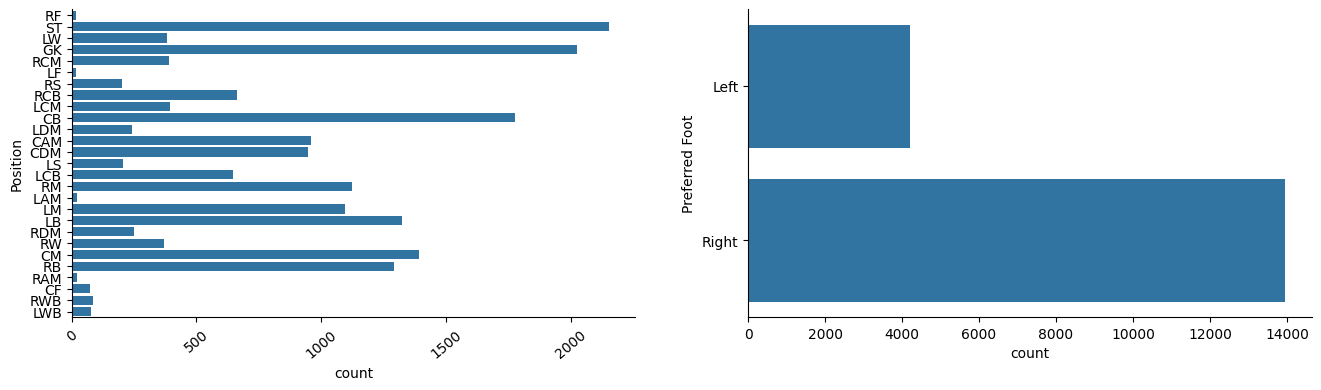

In [ ]:
fig = plt.figure(figsize=(16,4))
plt.subplot(121), seaborn.countplot(df.Position)
plt.xticks(rotation=40)
plt.subplot(122),seaborn.countplot(df['Preferred Foot'])
seaborn.despine()

#### Categóricas o discretas. crosstab

Dos categóricas o discretas:

crosstab, tabla de contingencia

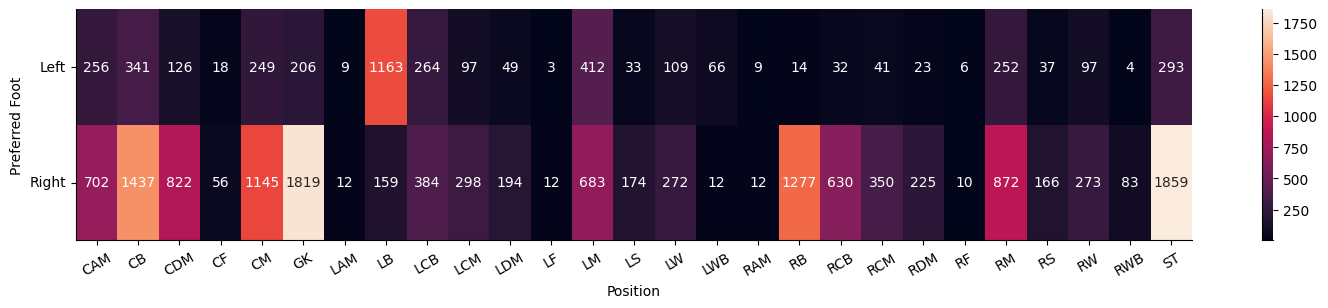

In [ ]:
fig = plt.figure(figsize=(18,3))
exp = pd.crosstab(index=df['Preferred Foot'],
            columns=df.Position)

seaborn.heatmap(exp, annot=True, fmt='g')
plt.xticks(rotation=30)
plt.yticks(rotation=0)
seaborn.despine()

## Vinos

In [ ]:
datos = load_wine() #base de datos la guardamos en la variable datos

In [ ]:
df = pd.DataFrame(datos.data, columns=datos.feature_names)
print(df.shape)
print('tabla con ', df.shape[0], 'filas (muestras de vinos) y  ',df.shape[1], 'columnas (características/info/datos)')


(178, 13)
tabla con  178 filas (muestras de vinos) y   13 columnas (características/info/datos)


In [ ]:
df.head(5)

,alcohol,malic_acid,ash,alcalinity_of_ash,magnesium,total_phenols,flavanoids,nonflavanoid_phenols,proanthocyanins,color_intensity,hue,od280/od315_of_diluted_wines,proline
0,14.23,1.71,2.43,15.6,127.0,2.80,3.06,0.28,2.29,5.64,1.04,3.92,1065.0
1,13.20,1.78,2.14,11.2,100.0,2.65,2.76,0.26,1.28,4.38,1.05,3.40,1050.0
2,13.16,2.36,2.67,18.6,101.0,2.80,3.24,0.30,2.81,5.68,1.03,3.17,1185.0
3,14.37,1.95,2.50,16.8,113.0,3.85,3.49,0.24,2.18,7.80,0.86,3.45,1480.0
4,13.24,2.59,2.87,21.0,118.0,2.80,2.69,0.39,1.82,4.32,1.04,2.93,735.0


### Variables numéricas

['alcohol', 'malic_acid', 'ash', 'alcalinity_of_ash', 'magnesium', 'total_phenols', 'flavanoids', 'nonflavanoid_phenols', 'proanthocyanins', 'color_intensity', 'hue', 'od280/od315_of_diluted_wines', 'proline']


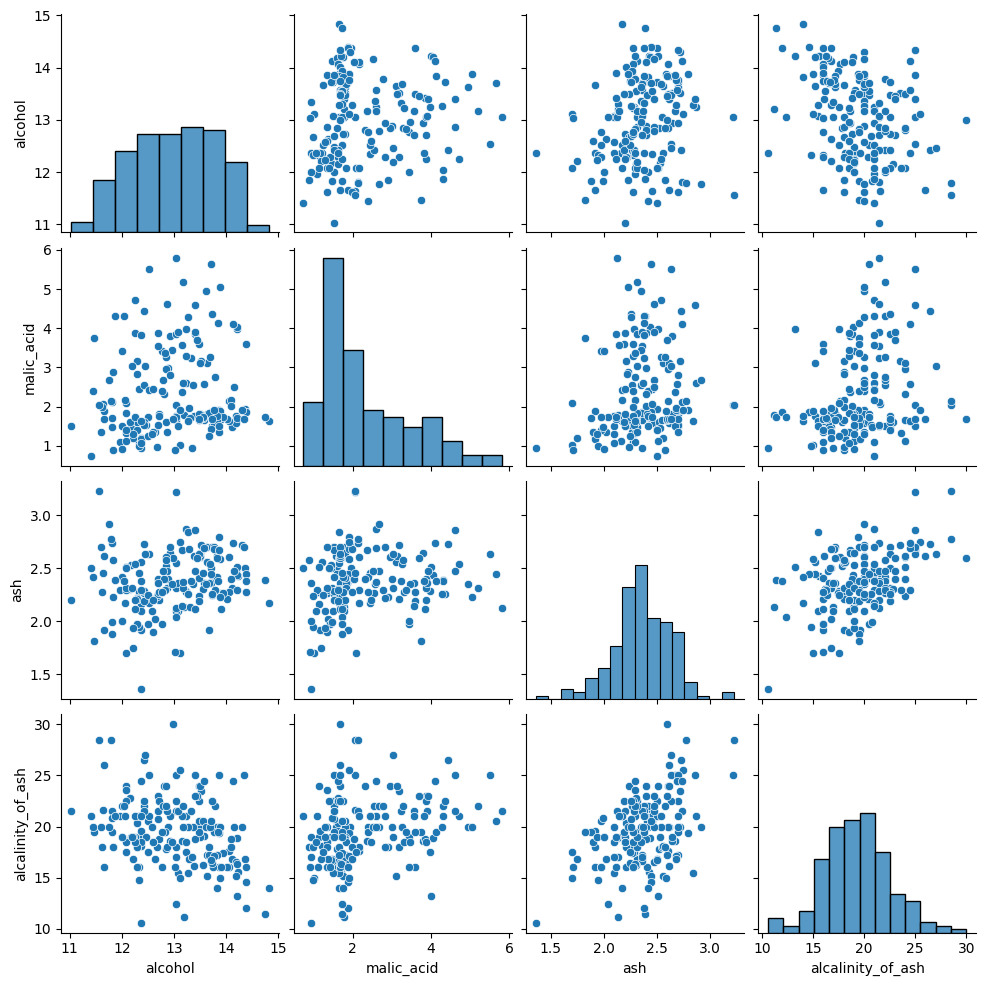

In [ ]:
columnas=datos.feature_names
print(columnas)
seaborn.pairplot(df[columnas[0:4]])
seaborn.despine()

### Variable categórica

In [ ]:
mini_df=df[columnas[0:4]].copy() #achico la base, quedan 4 variables/características numéticas
mini_df['clase']=datos.target #agregamos una variable categórica
print(datos.target_names)
mini_df.head(3)

['class_0' 'class_1' 'class_2']


,alcohol,malic_acid,ash,alcalinity_of_ash,clase
0,14.23,1.71,2.43,15.6,0
1,13.20,1.78,2.14,11.2,0
2,13.16,2.36,2.67,18.6,0


In [ ]:
mini_df.tail(3)

,alcohol,malic_acid,ash,alcalinity_of_ash,clase
175,13.27,4.28,2.26,20.0,2
176,13.17,2.59,2.37,20.0,2
177,14.13,4.10,2.74,24.5,2


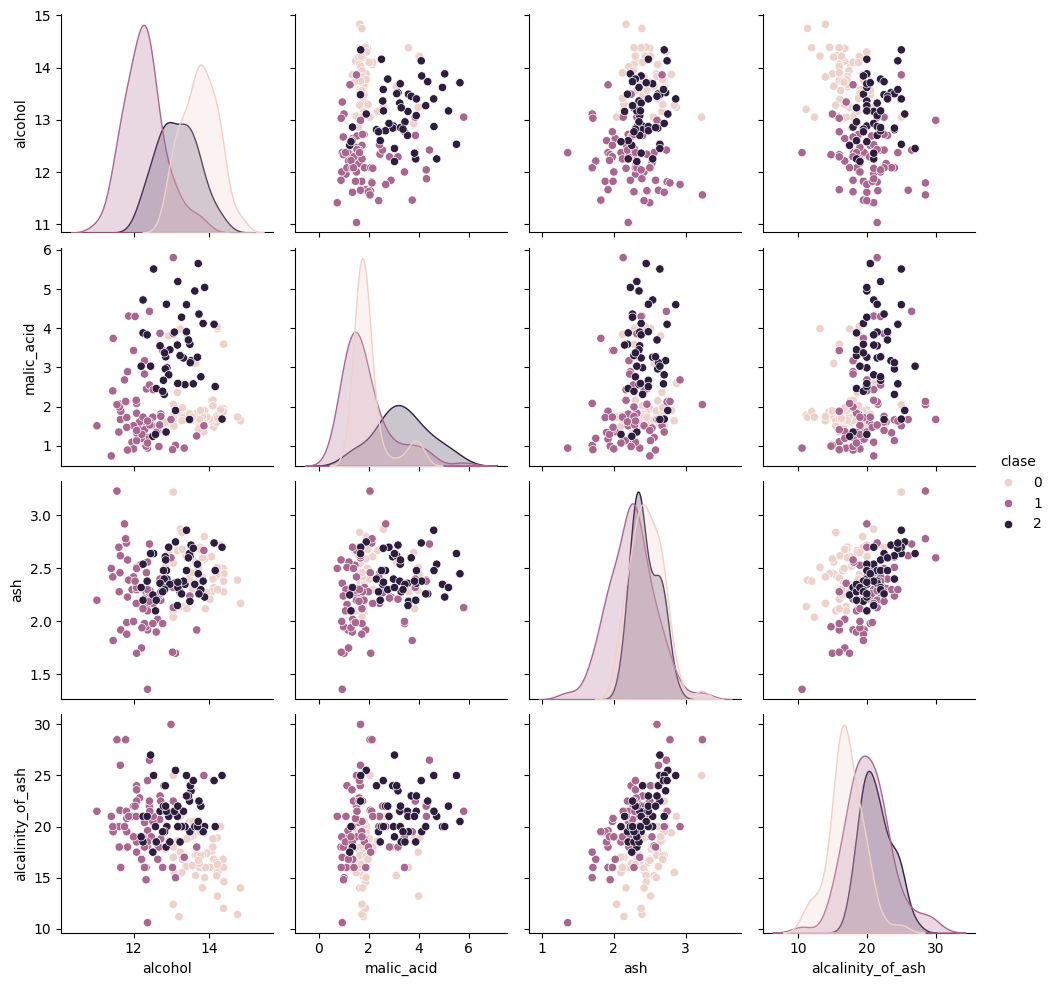

In [ ]:
seaborn.pairplot(mini_df,hue="clase")
seaborn.despine()

## Imagen
    



### Monocroma
Podemos definir una **imagen monocroma** (de un solo canal) como una función o arreglo bidimensional f.

En cada coordenada [x,y] tenemos el valor f[x,y]  que es la intensidad de la imagen en dicho punto. Para imágenes en grises (monocroma).



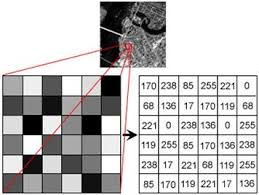

### stack - multibanda

Una **imagen satelital o stack** contiene varios canales o capas "apiladas"  que coinciden espacialmente.

Una imagen monocroma por canal o banda.

Puede pensarse como un arreglo o una función o arreglo tridimensional $ND$.

En cada coordenada $[i,j,k]$ (o bien $[k,i,j]$) tenemos el valor $ND_{i,j,k}$  que es la intensidad de la imagen en el punto o pixel ubicado en $[i,j]$ en el Canal o Banda $k$.

[fuente de la imagen](http://revistasbolivianas.umsa.bo/scielo.php?script=sci_arttext&pid=S2519-93822017000200012&lng=es&nrm=iso&tlng=es)
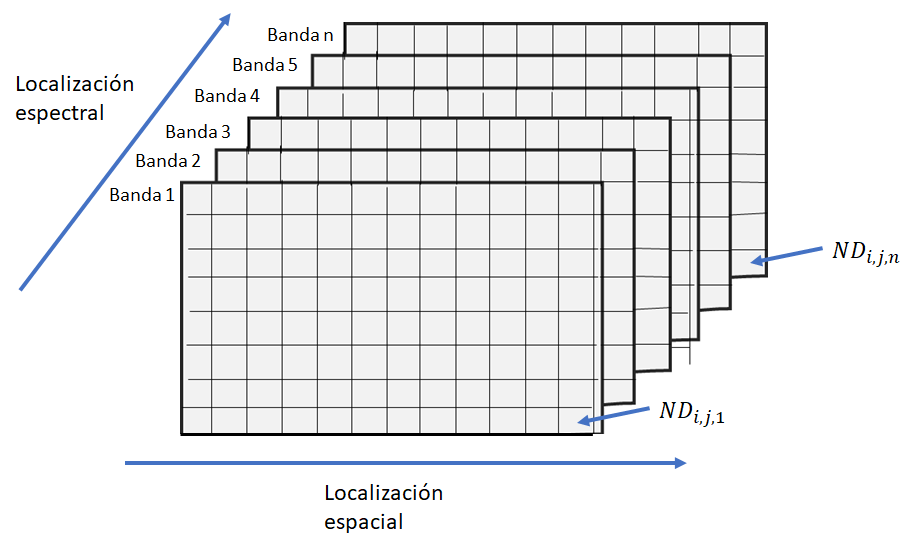

## Imagen satelital

La imagen que abriremos y con la que vamos a trabajar es una Landsat 9 OLI, descargada del portal EarthExplorer del USGS.

Mas informacion [aquí](https://doi.org/10.5066/P9OGBGM6) y [aquí](https://www.usgs.gov/landsat-missions/landsat-9)

La imagen corresponde a un recorte del producto

Es un área llena de lagunas de distintos tipos próximas a la localidad de Arias, provincia de Cordoba, cerca del límite con la provincia de Santa Fe. Las bandas (canales) presentes (1-7), han sido calibradas atmosfericamente y escaladas, expresando la reflectancia de superficie con valores entre 0-1:

* B1 Visible Coastal Aerosol (0.43 - 0.45 µm) 30-m
* B2 Visible Blue (0.450 - 0.51 µm) 30-m
* B3 Visible Green (0.53 - 0.59 µm) 30-m
* B4 Red (0.64 - 0.67 µm) 30-m
* B5 Near-Infrared (0.85 - 0.88 µm) 30-m
* B6 SWIR 1(1.57 - 1.65 µm) 30-m
* B7 SWIR 2 (2.11 - 2.29 µm) 30-m

## Subir y abrir un archivo en colab: imagen stack

primero debemos subir el archivo:

**'recL228083_20250909.tif'**

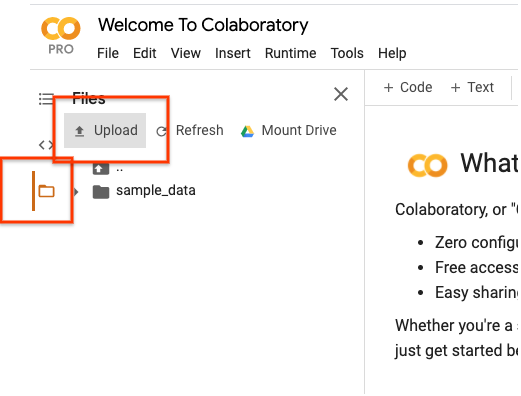

In [ ]:
imgsat = '/content/recL228083_20250909.tif' #imgsat = 'recL228083_20250909.tif'
with rasterio.open(imgsat) as src:
        # Lee todas las bandas
        # los datos tiene dimensiones (bands, rows, columns)
        imagen = src.read()
        # guarda los metadatos para usar despues
        profile = src.profile

RasterioIOError: /content/recL228083_20250909.tif: No such file or directory

In [ ]:
try:
    with rasterio.open(imgsat) as src:
        print("File opened successfully. File integrity seems OK.")
except rasterio.errors.RasterioIOError as e:
    print(f"Error opening file: {e}")
    print("The file might be corrupted or incomplete. Please check the file or try re-uploading it.")

In [ ]:
imagen.shape #arreglo tridimensional

In [ ]:
(can,fil, col)=imagen.shape
print('imagen con:'),
print(can, ' canales o bandas')
print( fil, ' filas')
print( col, ' columnas')
print( fil*col, 'pixeles (total)')


In [ ]:
imagen2=imagen.transpose(1,2,0)
imagen2.shape

### 7 Bandas

In [ ]:
plt.figure(figsize=(18,10))
for i in range(can):
  plt.subplot(3,3,(i+1))
  plt.imshow(imagen2[:,:,i],cmap='gray')
  plt.title('Banda '+str(i+1))
  plt.colorbar()
plt.show()

### RGB: Visible y falso color

* B1 Visible Coastal Aerosol (0.43 - 0.45 µm) 30-m
* B2 Visible Blue (0.450 - 0.51 µm) 30-m
* B3 Visible Green (0.53 - 0.59 µm) 30-m
* B4 Red (0.64 - 0.67 µm) 30-m
* B5 Near-Infrared (0.85 - 0.88 µm) 30-m
* B6 SWIR 1(1.57 - 1.65 µm) 30-m
* B7 SWIR 2 (2.11 - 2.29 µm) 30-m

In [ ]:
imagen.dtype #tipo de dato en cada lugar

In [ ]:
# valores para hacer streching de histograma para ver mas contrastada la imagen;
min_val, max_val = np.percentile(imagen2[:,:,0:4], (1, 99))
image_stretched =imagen2.copy()
image_stretched[:,:,0:4] = (imagen2 [:,:,0:4] - min_val) / (max_val - min_val)
image_stretched[image_stretched < 0] = 0
image_stretched[image_stretched > 1] = 1

In [ ]:
min_val, max_val = np.percentile(imagen2[:,:,4:], (1, 99))
image_stretched[:,:,4:] = (imagen2 [:,:,4:] - min_val) / (max_val - min_val)
image_stretched[image_stretched < 0] = 0
image_stretched[image_stretched > 1] = 1

In [ ]:
plt.figure(figsize=(18,10))
for i in range(can):
  plt.subplot(3,3,(i+1))
  plt.imshow(image_stretched[:,:,i],cmap='gray')
  plt.title('Banda '+str(i+1))
  plt.colorbar()
plt.show()

In [ ]:
plt.figure(figsize=(18,10))
RGB_visible=image_stretched[:,:,[3,2,1]]
RGB_falso_color=image_stretched[:,:,[4,5,6]]
#plt.figure(figsize=(18,10))
plt.subplot(1,2,1)
plt.imshow(RGB_visible)
plt.title('RGB_visible')
plt.subplot(1,2,2)
plt.imshow(RGB_falso_color)
plt.title('RGB_falso_color')
plt.show()

Ahora mis datos van a ser los pixeles,
si pasamos una imagen a Data frame:

En el data Frame un pixel estará ubicado en la fila $i'$ (y en la imagen estará ubicado en un lugar [i,j]) en el Data frame se pierde la espacialidad, salvo que se la guarde en alguna columna.

Las columnas o variables del data frame que describen a cada pixel serán las bandas.


### Pixeles a Data Frame

In [ ]:
ind=np.indices((fil,col)) # arreglo con matriz de filas y  matriz de columnas
cant_pixeles=fil*col


data0=np.zeros([cant_pixeles,(can+2)],dtype='float32')
data0[:,0]=ind[0].flatten() #filas
data0[:,1]=ind[1].flatten() #columnas
for i in range(can):
  data0[:,i+2]=imagen[i,:,:].flatten()

df = pd.DataFrame(data0, columns=["fila", "columna","B1","B2","B3","B4","B5","B6","B7"])
print(df.shape)
print('Base de pixeles:')
df.head()

print(df.shape)
print('Base de pixeles:')
df.head()

In [ ]:
variables=["B1","B2","B3","B4","B5","B6","B7"]

variable1=variables[6]
variable2=variables[2]

f1 = df[variable1].values
f2 = df[variable2].values

plt.scatter(f1, f2,c='gray', s=1)
plt.xlabel(variable1)
plt.ylabel(variable2)
plt.show()

## Datos: Formalizamos un poco

como se acomodan los datos para aprendizaje automático...


Datos:

El individuo, objeto, muestra, pixel nro $i$ esá representado por un vector con características o datos que lo caracterizan:

$\underline{x}_i=(x_{i1},..,x_{im})$

$m$  es la cantidad de variables/medidas/características

$i=1,..,n$,

$n=$ cantidad de observaciones/registros/muestras/objetos

Luego todos los datos se guardan en una matriz con $n$ filas y $m$ columnas:

$X=\begin{bmatrix}
 x_{1 1}& \cdots  & x_{1 m}\\
 \vdots &  \ddots &\vdots \\
 x_{n 1}& \cdots  & x_{n m}
\end{bmatrix}$

Cada fila $i$ es un individuo/objeto/muestra

Cada columna $j$ está a sociada a una característica


Cuando:

- $x_{i j}\in R$ -> variable $j$ es numérica (contínua, contínua discretizada o discreta}

- $x_{i j} \in \{c_1,,..,c_k\}$ -> variable $j$ es categórica,



con muuucho cuidado se puede pasar las variables categóricas a numéricas...

# Aprendizaje automático No supervisado

Clustering

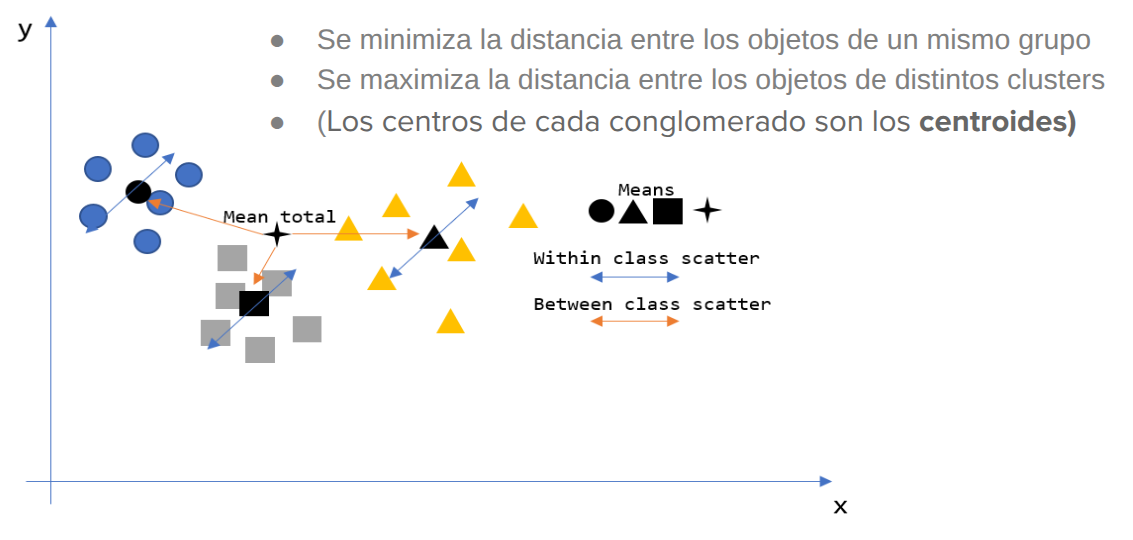

### k-medias

In [ ]:
# Librerías para Clustering
from sklearn.cluster import KMeans, DBSCAN
from sklearn import preprocessing
from sklearn.metrics import silhouette_score
from collections import Counter

In [ ]:
# Se agrupan los datos usando Kmedias en 4 clusters (cantidad elegida de forma arbitraria)
kmeans = KMeans(n_clusters=4)
kmeans.fit(df)

In [ ]:
X=data0[:,2:] # solo las bandas (sin fila columna)

In [ ]:
# Se agrupan los datos usando Kmedias en 3 clusters (cantidad elegida de forma arbitraria)
kmeans = KMeans(n_clusters=3)
kmeans.fit(X)

In [ ]:
# resultados
print(kmeans.labels_)
print(kmeans.labels_.shape)

In [ ]:
df_clusters=df.copy() #nuevo Data Frame
df_clusters['kmedias_3']=kmeans.labels_
df_clusters.head()

In [ ]:
variable1=variables[3]
variable2=variables[2]

f1 = df[variable1].values
f2 = df[variable2].values
km = kmeans.labels_
imagen_kmedias=np.reshape(km, (fil,col))
aleat=np.random.randint(0, len(f1), 50000)#para graficar algunos pixeles

In [ ]:
plt.figure(figsize=(18,8))
plt.subplot(1,2,1)
plt.scatter(f1[aleat], f2[aleat],c=km[aleat], s=1)
plt.xlabel(variable1)
plt.ylabel(variable2)

plt.subplot(2,2,2)
plt.imshow(RGB_visible,cmap='gray')
plt.colorbar()

plt.subplot(2,2,4)
plt.imshow(imagen_kmedias)
plt.colorbar()
plt.show()

# Aprendizaje automático supervisado

**Base, Datos:**

 $X=\begin{bmatrix}
 x_{1 1}& \cdots  & x_{1 m}\\
 \vdots &  \ddots &\vdots \\
 x_{n 1}& \cdots  & x_{n m}
\end{bmatrix}$
y además $y=(y_{1},..,y_{n})$, o $ y=\begin{bmatrix}
 y_{1}\\
 \vdots \\
 y_{n}
\end{bmatrix}$



cada fila  $\underline{x}_i=(x_{i1},..,x_{im})$, acompañada de su etiqueta (colocada por experto/a, diagnóstico, verifiación, verdad de campo, ground truth):


$(\underline{x}_i,y_i)_{i=1..,n}$,

$m$ variables o características

$n=$ muestras u objetos

Cada  $y_i$ target, objetivo o etiqueta

Cuando:

- $y_i\in \{c_1,,..,c_k\}$, categórica, $\rightarrow$ **Clasificación**, donde $k=$ cantidad de clases.
- $y_i\in R$, numérica, $\rightarrow$ **Regresión**

- Caso especial: $y_i\in \{0,1\}\equiv \{False, True\}\equiv \{Negativo, Positivo\}$ $\rightarrow$ Regresión logística, clasificación binaria

El **Aprendizaje automático supervisado**

Busca predecir o "adivinar" la etiqueta $y_i$ usando $\underline{x}_i=(x_{i1},..,x_{im})$.

Busca aprender (de los datos), encontrar una función $f$ tal que

$f((x_{i1},..,x_{im}))=y_i$  o bien $f ( (x_{i1},..,x_{im}))\approx y_i$ para todos los $i$ y para cualquier nuevo vector de datos.

**Entrada:** $\;(x_{1},..,x_{m}) $   

**Modelo:** $\; f$

**Salida:** $ \; y$


$(x_{1},..,x_{m}) \rightarrow \, \sqsubset f \sqsupset  \,\rightarrow \, y$

$f: (x_{1},..,x_{m}) \rightarrow y$


## Clasificación supervisada

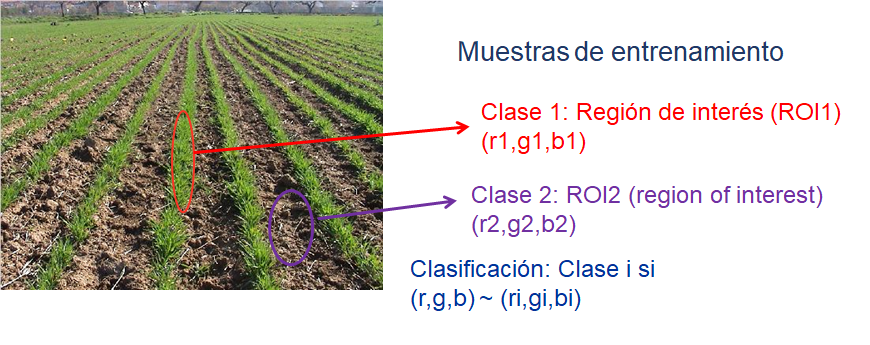

### Algunos métodos

####  K vecinos más cercanos, K-NN

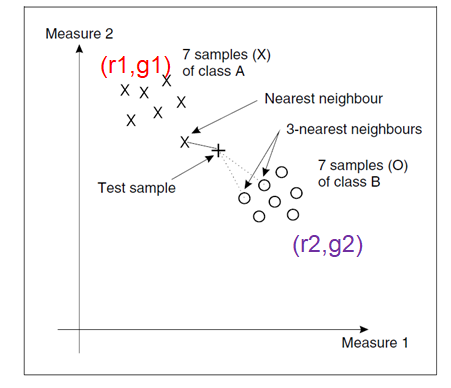

#### SVM, máquinas de vectores de soporte (opcional)

Para dos clases, se puede adaptar para más.

La versión más simple: separación lineal

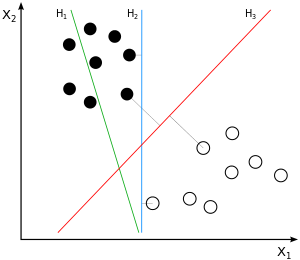

#### Arbol de decisión

ejemplo usando tres variables o características: NDVI (índice verde). IS (índice de salinidad) y MNWI

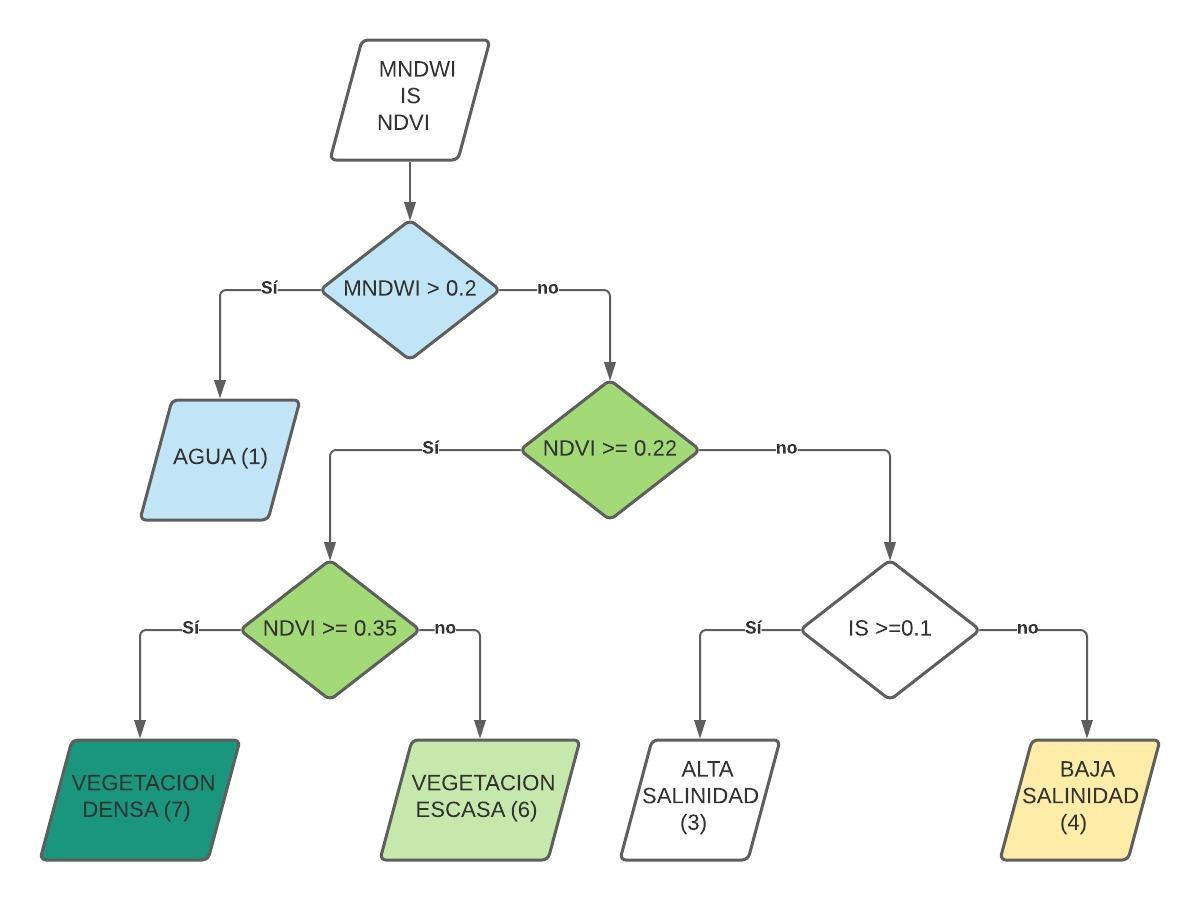

#### Random Forest

Consiste en entrenar varios árboles (Forest) de decisión, cada uno entrenado con un re-muestreo aleatorio (Random) del conj. de entrenamiento. Una vez entrenados, dada una nueva muestra  $(x_{1},..,x_{m})$ cada arbol da su veredicto y para esa muestra la predicción será la clase $y$ más votada.

para más info ver: https://scikit-learn.org/stable/modules/generated/sklearn.ensemble.RandomForestClassifier.html

### Evaluación en clasificación supervisada

#### Matriz de confusión


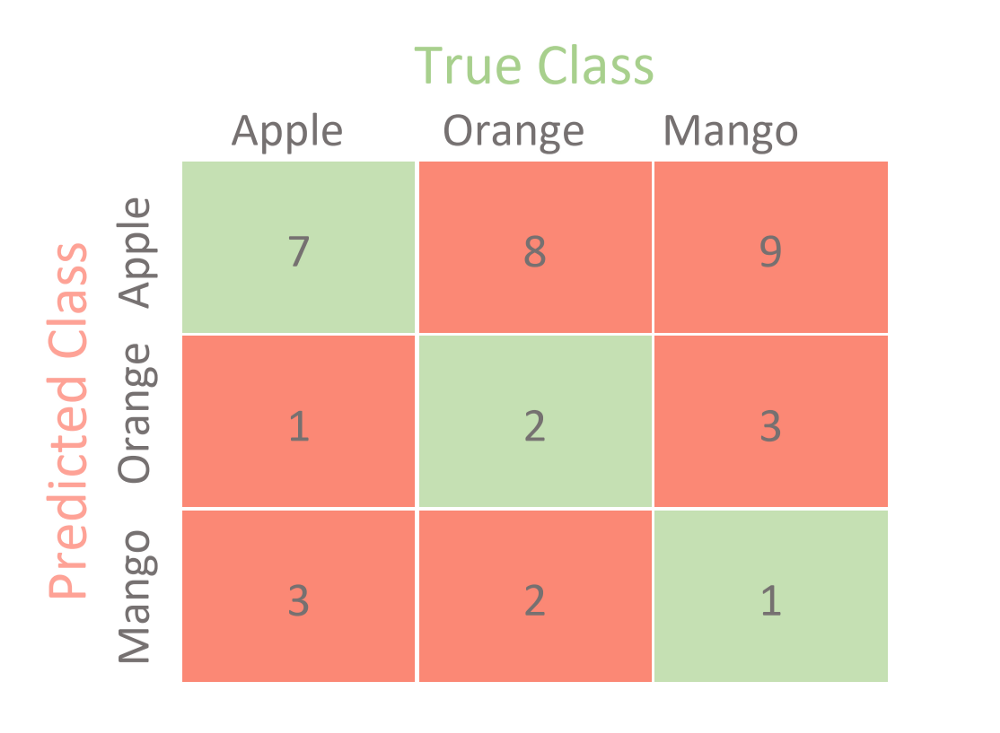




-Coeficiente Kappa (para dos o más clases)


**Matriz de Confusión para dos clases: Positivo y Negarivo**


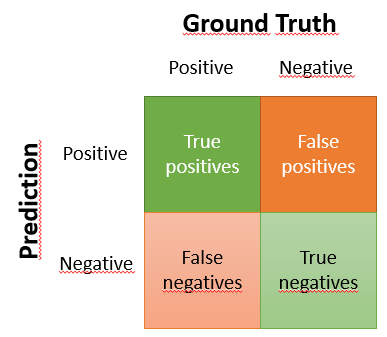

Precision $p=\frac{TP}{FP+TP}=$ Predictivo positivo (la proporción de los positivos verdaderos de los que el algoritmo predijo como positivos)

Recall $r=\frac{TP}{TP+FN}=$ Sensibilidad (la proporción de los positivos vedaderos de los que realmente eran positivos)

F1-score $=\frac{2\, p \, r}{p+r}$

Accuracy $=\frac{TP+TN}{TP+FP+TN+FN}=$porcentaje de aciertos

Coeficiente de correlación de Mathews;
 $\phi= \frac{TP \; TN - FP \; FN }{\sqrt{(TP+FN)(FP+TN)(TP+FP)(FN+TN)}}$


## Etiquetamos algunos pixeles

In [ ]:
RGB_visible2=RGB_visible.copy()
RGB_visible2[660:800,1800:1930,2]=1 #ROI_agua
#RGB_visible2[530:610,1000:1100,2]=1 #ROI_agua?
RGB_visible2[275:380,220:350,1]=1 #ROI_suelo
RGB_visible2[60:123,3:35,0]=1 #ROI_cultivo

In [ ]:
plt.figure(figsize=(18,10))
plt.subplot(2,2,1)
plt.imshow(RGB_visible2)
plt.subplot(2,3,4)
#plt.imshow(RGB_visible[530:610,1000:1100]) #ROI_agua
#plt.title('ROI AGUA?')
plt.imshow(RGB_visible[680:800,1800:1930]) #ROI_agua
plt.title('ROI AGUA')
plt.subplot(2,3,5)
plt.imshow(RGB_visible[275:380,220:350])
plt.title('ROI_suelo')
plt.subplot(1,3,3)
plt.imshow(RGB_visible[60:123,3:35])
plt.title('ROI_cultivo')
plt.show()

In [ ]:
ROI_agua=imagen2[660:800,1800:1930,:] #ROI_agua
#ROI_agua=imagen2[530:610,1000:1100,:] #ROI_agua?
ROI_suelo=imagen2[275:380,220:350,:] #ROI_suelo
ROI_cultivo=imagen2[60:123,3:35,:] #ROI_cultivo


In [ ]:
(a1,b1,c1)=ROI_agua.shape
cont1=a1*b1
print(cont1)
(a2,b2,c)=ROI_suelo.shape
cont2=(a2*b2)
print(cont2)
(a3,b3,c3)=ROI_cultivo.shape
cont3=(a3*b3)
print(cont3)
cont=cont1+cont2+cont3

data=np.zeros([cont,(can+1)],dtype='float32')

for i in range(can):
  data[:cont1,i]=imagen2[660:800,1800:1930,i].flatten()
  data[cont1:(cont1+cont2),i]=imagen2[275:380,220:350,i].flatten()
  data[(cont1+cont2):,i]=imagen2[60:123,3:35,i].flatten()

data[:cont1,can]=0
data[cont1:(cont1+cont2),can]=1
data[(cont1+cont2):,can]=2
df_etiq = pd.DataFrame(data, columns=["B1","B2","B3","B4","B5","B6","B7","clase"])
print(df_etiq.shape)
print('Base de pixeles etiquetados:')
df_etiq.head(3)

In [ ]:
df_etiq.tail(3)

## Práctica

Librerías necesarias

In [ ]:
import pandas as pd
import seaborn as sns
import numpy as np

from sklearn.datasets import load_wine
from sklearn.model_selection import train_test_split

from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import (roc_auc_score,
                             make_scorer,
                             classification_report,
                             roc_curve,
                             f1_score,
                             matthews_corrcoef,
                             precision_score,
                             recall_score,
                             confusion_matrix)


In [ ]:
X_e=data[:,:can]#datos de entrenamiento
y_e=data[:,can]#etiquetas de entrenamiento

In [ ]:
#Entrenamos un Árbol de desición y predecimos:
tree = DecisionTreeClassifier(random_state=17)
tree.fit(X_e, y_e)

arbol_imagen=tree.predict(data0[:, 2:])
pred_entren=tree.predict(X_e)

print('predicciones: ', pred_entren)
print('verdaderos:', y_e)

print(f"Tree Accuracy: {tree.score(X_e, y_e)}")


In [ ]:
print(confusion_matrix(pred_entren, y_e))
pd.crosstab(index=pred_entren,
            columns=y_e)


In [ ]:
variable1=variables[3]
variable2=variables[2]

f1 = df[variable1].values
f2 = df[variable2].values

imagen_arbol=np.reshape(arbol_imagen, (fil,col))
aleat=np.random.randint(0, len(f1), 50000)#para graficar algunos pixeles

In [ ]:
plt.figure(figsize=(18,8))
plt.subplot(1,2,1)
plt.scatter(f1[aleat], f2[aleat],c=arbol_imagen[aleat], s=1)
plt.xlabel(variable1)
plt.ylabel(variable2)

plt.subplot(2,2,2)
plt.imshow(RGB_visible,cmap='gray')
plt.colorbar()

plt.subplot(2,2,4)
plt.imshow(imagen_arbol)
plt.colorbar()
plt.show()

In [ ]:
#Entrenamos un bosque alatorio (Random Forest) y predecimos:

rf = RandomForestClassifier(random_state=11, n_estimators=20,
                               class_weight="balanced", max_features="log2")
rf.fit(X_e, y_e)

rf_imagen=rf.predict(data0[:, 2:])
rf_entren=rf.predict(X_e)

print('predicciones: ', rf_entren)
print('verdaderos:', y_e)

print(f"RF Accuracy: {rf.score(X_e, y_e)}")

In [ ]:
variable1=variables[3]
variable2=variables[2]

f1 = df[variable1].values
f2 = df[variable2].values

imagen_rf=np.reshape(rf_imagen, (fil,col))
aleat=np.random.randint(0, len(f1), 50000)#para graficar algunos pixeles

In [ ]:
plt.figure(figsize=(18,8))
plt.subplot(1,2,1)
plt.scatter(f1[aleat], f2[aleat],c=rf_imagen[aleat], s=1)
plt.xlabel(variable1)
plt.ylabel(variable2)

plt.subplot(2,2,2)
plt.imshow(RGB_visible,cmap='gray')
plt.colorbar()

plt.subplot(2,2,4)
plt.imshow(imagen_rf)
plt.colorbar()
plt.show()

In [ ]:
plt.figure(figsize=(18,8))

plt.subplot(2,2,1)
plt.imshow(RGB_visible,cmap='gray')
plt.colorbar()

plt.subplot(2,2,3)
plt.imshow(imagen_kmedias)
plt.title('Clustering K-medias')
plt.colorbar()

plt.subplot(2,2,2)
plt.imshow(imagen_arbol)
plt.title('Arbol de desición')
plt.colorbar()

plt.subplot(2,2,4)
plt.imshow(imagen_rf)
plt.title('Random Forest')
plt.colorbar()


plt.show()

## Matriz de confusión RF vs árbol

Filas: Random Forest

Columnas: árbol de desición

In [ ]:
print( confusion_matrix(rf_imagen, arbol_imagen))
pd.crosstab(index=rf_imagen,
            columns=arbol_imagen)#, rownames=['rf_0','rf_1','rf_2'], colnames=['arbol_0','arbol_1','arbol_2'])

## Matriz de confusión árbol vs k-medias

Filas: árbol de desición

Columnas: K-medias

In [ ]:
pd.crosstab(index=arbol_imagen,
            columns=km)

## Matriz de confusión RF vs k-medias

Filas: Random Forest

Columnas: k-medias

In [ ]:
pd.crosstab(index=rf_imagen,
            columns=km)